# Import Dependencies

In [34]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Define Document

In [35]:
sentence = """Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

# Text Preprocessing

In [36]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Pada bagian ini, teks bahasa Inggris dipecah menjadi beberapa kalimat menggunakan fungsi sent_tokenize() dari NLTK.

Fungsi ini secara otomatis mengenali batas antar kalimat berdasarkan tanda baca seperti titik (.), tanda tanya (?), dan tanda seru (!).

Hasilnya adalah list yang berisi kalimat-kalimat terpisah, sehingga memudahkan proses analisis lebih lanjut seperti TF-IDF atau text summarization.

In [37]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print(sent_token)

['Manchester City makes history by winning Club World Cup\n\nManchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.', 'Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.', 'The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.', '“We’ve shown over the past 12 months we are the best team in the world.', 'Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.', '“To win these five trophies – for me, the five biggest prizes available to us – is incredible.', 'I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.', 'I could

Kode ini mengubah kalimat menjadi angka berdasarkan seberapa penting kata-katanya.

In [38]:
# Training TF-IDF Vectorizer on sentences
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(sent_token)

Pada kode ini, teks bahasa Inggris dipecah menjadi beberapa kalimat menggunakan sent_tokenize().

Berbeda dengan versi Bahasa Indonesia, pada kode ini tidak digunakan Sastrawi karena stopwords sudah ditangani langsung oleh *TfidfVectorizer* dengan parameter stop_words='english'.

Setiap kalimat kemudian diubah menjadi representasi numerik menggunakan TF-IDF, yang menunjukkan tingkat kepentingan kata dalam kalimat tersebut.

In [39]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Sentence tokenization
sent_token = sent_tokenize(sentence)
print("Tokenized sentences:")
for sent in sent_token:
    print(sent)

# No Sastrawi (English version)
cleaned_sentences = sent_token

print("\nCleaned sentences (English):")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# TF-IDF with English stopwords
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse):")
print(features)

print("\nShape of the Feature Matrix:")
print(features.shape)

# Feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names:")
print(feature_names)

# TF-IDF for first sentence
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first sentence (sorted):")
    print(first_sentence_tfidf_df)
else:
    print("\nNo sentences to process.")

Tokenized sentences:
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
“We’ve shown over the past 12 months we are the best team in the world.
Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible.
I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
I couldn’t 

Kode ini menampilkan grafik kata-kata penting dalam kalimat pertama berdasarkan TF-IDF.

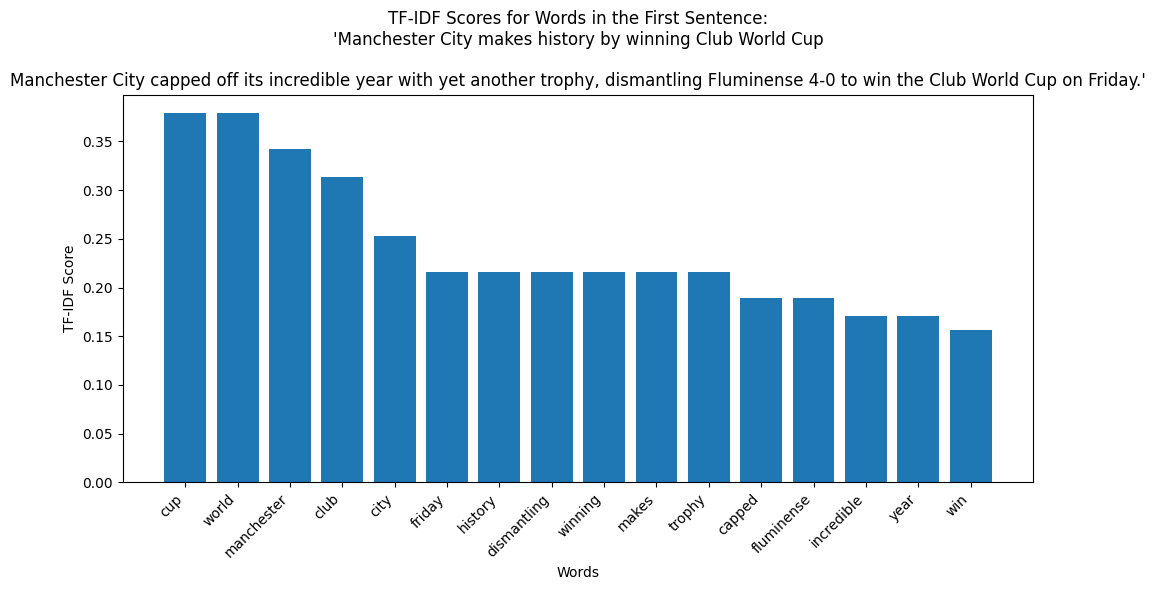

In [40]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd

# Sentence tokenization
sent_token = sent_tokenize(sentence)

# No stopword remover (handled by TF-IDF)
cleaned_sentences = sent_token

# TF-IDF with English stopwords
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Function (pastikan sudah ada atau definisikan)
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return tfidf_df

# TF-IDF untuk kalimat pertama
if cleaned_sentences:
    first_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualisasi
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Sentence:\n'{first_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No sentences to visualize.")

# Calculate Sentence Score

Kode ini memberi skor pada setiap kalimat untuk mengetahui mana yang paling penting, lalu menampilkannya dalam grafik.

**List of Sentences:**
1. Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
2. Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
3. The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
4. “We’ve shown over the past 12 months we are the best team in the world.
5. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
6. “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
7. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside the

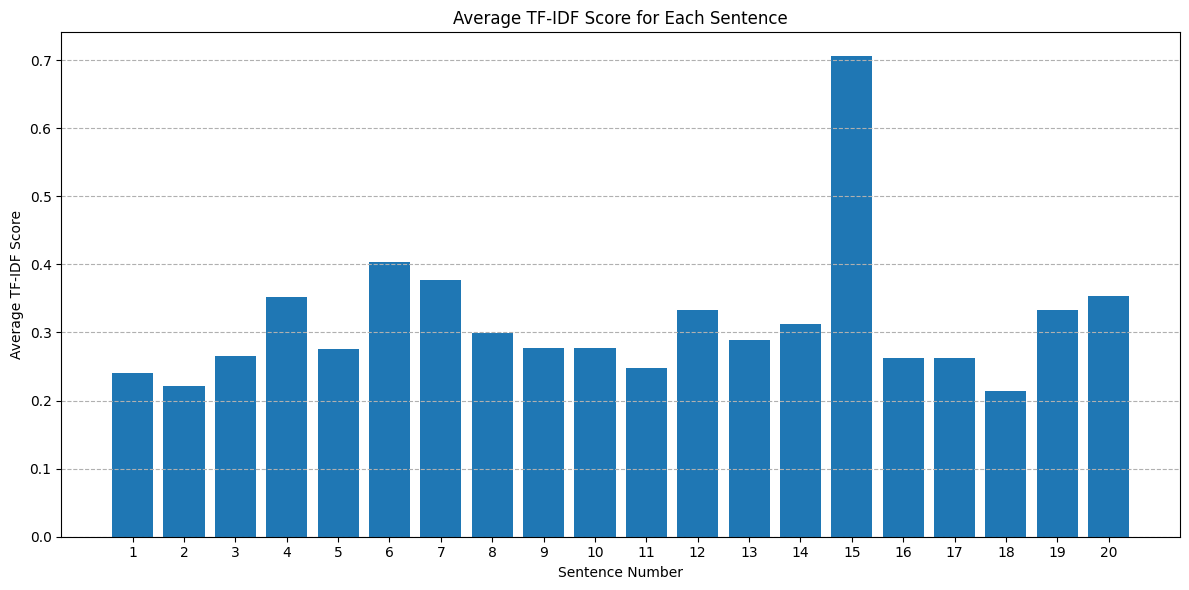

In [41]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Sentence tokenization
sent_token = sent_tokenize(sentence)

# No Sastrawi (English version)
cleaned_sentences = sent_token

# TF-IDF with English stopwords
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# List sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Define Threshold

Pada kode ini, setiap kalimat dalam teks bahasa Inggris diberikan skor berdasarkan rata-rata nilai TF-IDF.

Stopwords bahasa Inggris dihapus secara otomatis menggunakan stop_words='english', sehingga hanya kata-kata penting yang diperhitungkan.

Setelah semua kalimat memiliki skor, dihitung nilai rata-rata dari seluruh skor tersebut yang disebut sebagai threshold.

Threshold ini digunakan sebagai batas untuk menentukan kalimat mana yang dianggap penting dalam proses summarization.

In [42]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Sentence tokenization
sent_token = sent_tokenize(sentence)

# No Sastrawi (English)
cleaned_sentences = sent_token

# TF-IDF with English stopwords
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_scores = []

# Calculate sentence TF-IDF score
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Threshold
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.31514140188014117


Kode ini menghitung seberapa penting kata “cup” di setiap kalimat.

In [51]:
from nltk.tokenize import word_tokenize
import math

# List sentences (English)
sentences = sent_token  # dari hasil sent_tokenize sebelumnya

# Function TF
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function IDF
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(
        1 for doc in all_documents if term.lower() in word_tokenize(doc.lower())
    )
    return math.log(len(all_documents) / num_documents_with_term) if num_documents_with_term > 0 else 0

# Gunakan langsung sentences sebagai cleaned data
all_cleaned_sentences = sentences

# TF-IDF untuk kata "cup"
tfidf_scores = {}

for i, sent in enumerate(sentences):
    tf = calculate_tf("cup", sent)
    idf = calculate_idf("cup", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Output
print("TF-IDF Score for 'cup' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# IDF keseluruhan
overall_idf = calculate_idf("cup", all_cleaned_sentences)
print(f"\nOverall IDF for 'cup': {overall_idf:.4f}")

TF-IDF Score for 'cup' in each sentence:
Sentence 1: 0.1396
Sentence 2: 0.1096
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000

Overall IDF for 'cup': 2.3026


In [45]:
#threshold = sum(sent_scores)/len(sent_scores) # Average of Sentence Scores
#threshold

# Get Sentences

Kode ini memilih kalimat paling penting dari teks bahasa Inggris, lalu menggabungkannya jadi ringkasan.

In [49]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Sentence tokenization
sent_token = sent_tokenize(sentence)

# No Sastrawi (English version)
cleaned_sentences = sent_token

# TF-IDF with English stopwords
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(cleaned_sentences)

# Hitung skor tiap kalimat
sent_scores = []
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Threshold
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("Threshold (Average of Sentence Scores):", threshold)

# Summary
final_summ = ""

print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ += " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.31514140188014117

**Summary Sentences (above or equal to the threshold):**
- “We’ve shown over the past 12 months we are the best team in the world.
- “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
- I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
- Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
- “As a manager it is what I am most proud of; that we are always there.
- The champion heads back to England where it faces a tough title defence in the Premier League.
- It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.

**Final Summary:**
“We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this

In [52]:
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import math

# Gunakan hasil sentence tokenization sebelumnya
sentences = sent_token

# Function TF
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function IDF
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(
        1 for doc in all_documents if term.lower() in word_tokenize(doc.lower())
    )
    return math.log(len(all_documents) / num_documents_with_term) if num_documents_with_term > 0 else 0

# TF-IDF manual untuk kata "cup"
tfidf_scores = {}
all_cleaned_sentences = sentences

for i, sentence in enumerate(sentences):
    tf = calculate_tf("cup", sentence)
    idf = calculate_idf("cup", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Output manual
print("TF-IDF Score for 'cup' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# IDF keseluruhan
overall_idf = calculate_idf("cup", all_cleaned_sentences)
print(f"\nOverall IDF for 'cup': {overall_idf:.4f}")

# TF-IDF pakai sklearn
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    cup_index = list(feature_names).index("cup")
    print("\nTF-IDF Score for 'cup' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, cup_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'cup' not found in the vocabulary.")

TF-IDF Score for 'cup' in each sentence:
Sentence 1: 0.1396
Sentence 2: 0.1096
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000

Overall IDF for 'cup': 2.3026

TF-IDF Score for 'cup' using TfidfVectorizer:
Sentence 1: 0.3790
Sentence 2: 0.3861
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000


In [53]:
final_summ

' “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'

In [54]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  “We’ve shown over the past 12 months we are the best team in the world.
-  “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
-  I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
-  Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
-  “As a manager it is what I am most proud of; that we are always there.
-  The champion heads back to England where it faces a tough title defence in the Premier League.
-  It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.


# Summarization Result

In [55]:
final_summ

' “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'